# Business Simulation and Lead Prioritization

## Objective
The goal of this notebook is to simulate how the selected lead scoring model can be used in a real-world business workflow.

## Business Perspective
In practice, sales teams cannot contact every lead with the same level of effort.

A lead scoring system helps prioritize the most promising prospects so that resources can be allocated more efficiently.

## What This Notebook Covers
- generate lead scores
- rank leads by conversion probability
- analyze the top-ranked segments
- quantify the business value of prioritization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')


In [2]:
df = pd.read_csv("/Users/omarpiro/ML_DL_Projects/AI_LEAD_SCORE/data/raw/bank+marketing/bank/bank-full.csv", sep=";")
df['target'] = df['y'].map({'no': 0, 'yes': 1})
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [3]:
drop_cols = ['y', 'target', 'duration']

X = df.drop(columns=drop_cols)
y = df['target']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

ordinal_cols = ['education']
ordinal_categories = [['unknown', 'primary', 'secondary', 'tertiary']]
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print('Categorical features:', categorical_cols)
print('Numerical features:', numerical_cols)
print('Ordinal columns:', ordinal_cols)
print('Nominal columns:', nominal_cols)


Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Ordinal columns: ['education']
Nominal columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (36168, 15)
Test shape: (9043, 15)


In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('nom', nominal_transformer, nominal_cols)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## Lead Scoring Simulation

The selected model is trained and used to assign a conversion probability score to each lead in the test set.

These scores are then used to rank leads from highest to lowest priority.


In [6]:
business_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric='logloss'
    ))
])

business_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [7]:
lead_scores = business_model.predict_proba(X_test)[:, 1]

scored_leads = X_test.copy()
scored_leads['y_true'] = y_test.values
scored_leads['score'] = lead_scores

scored_leads = scored_leads.sort_values(by='score', ascending=False)
scored_leads.head(10)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y_true,score
43122,20,student,single,secondary,no,215,no,no,cellular,24,feb,1,92,6,success,1,0.990227
43579,41,unemployed,married,tertiary,no,0,no,no,cellular,29,apr,1,181,3,success,1,0.986984
43135,25,student,single,secondary,no,469,no,no,cellular,24,feb,1,187,2,success,0,0.986804
45098,44,technician,single,unknown,no,11115,no,no,cellular,25,oct,1,185,4,success,0,0.986613
44016,45,management,married,unknown,no,2724,no,no,cellular,28,jun,2,182,1,success,1,0.986360
41241,59,unemployed,married,secondary,no,1047,no,no,cellular,21,aug,1,184,3,success,1,0.985136
45126,54,technician,married,tertiary,no,876,no,no,cellular,27,oct,3,541,3,success,1,0.984838
42322,24,blue-collar,married,secondary,no,272,no,no,cellular,16,nov,2,94,2,success,1,0.984380
42753,69,retired,divorced,secondary,no,4572,no,no,cellular,27,jan,2,92,3,success,0,0.982301
43005,60,retired,married,secondary,no,523,no,no,cellular,11,feb,1,182,3,success,1,0.982156


## Top-Ranked Leads

The highest-scoring leads represent the most promising prospects according to the model.

👉 In a real business setting, these leads would be prioritized for outreach, follow-up, or high-touch sales actions.


In [8]:
scored_leads[['score', 'y_true']].head(20)


,score,y_true
43122,0.990227,1
43579,0.986984,1
43135,0.986804,0
45098,0.986613,0
44016,0.986360,1
41241,0.985136,1
45126,0.984838,1
42322,0.984380,1
42753,0.982301,0
43005,0.982156,1


In [9]:
def precision_at_k(df, k):
    top_k = int(len(df) * k)
    return df.iloc[:top_k]['y_true'].mean()

for k in [0.1, 0.2, 0.3, 0.5]:
    print(f'Precision@{int(k*100)}%: {precision_at_k(scored_leads, k):.3f}')


Precision@10%: 0.521
Precision@20%: 0.362
Precision@30%: 0.278
Precision@50%: 0.193


In [10]:
baseline_conversion_rate = scored_leads['y_true'].mean()
print(f'Baseline conversion rate: {baseline_conversion_rate:.3f}')


Baseline conversion rate: 0.117


In [11]:
business_summary = []

for k in [0.1, 0.2, 0.3, 0.5]:
    p_at_k = precision_at_k(scored_leads, k)
    uplift = p_at_k / baseline_conversion_rate
    business_summary.append({
        'Top Segment': f'Top {int(k*100)}%',
        'Conversion Rate': round(p_at_k, 3),
        'Baseline Rate': round(baseline_conversion_rate, 3),
        'Uplift': round(uplift, 2)
    })

business_summary_df = pd.DataFrame(business_summary)
business_summary_df


,Top Segment,Conversion Rate,Baseline Rate,Uplift
0,Top 10%,0.521,0.117,4.45
1,Top 20%,0.362,0.117,3.09
2,Top 30%,0.278,0.117,2.38
3,Top 50%,0.193,0.117,1.65


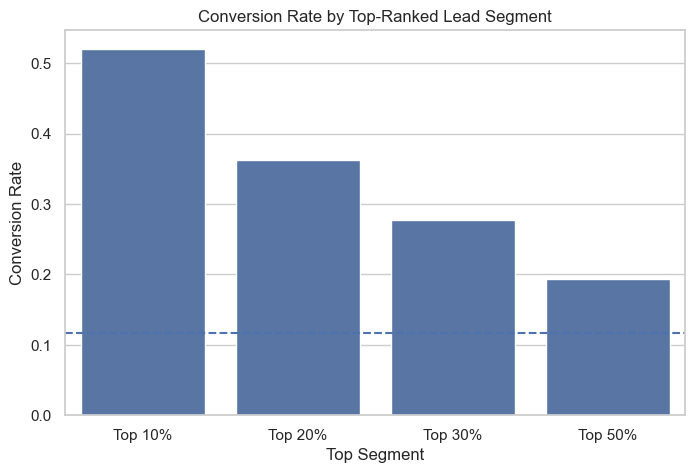

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=business_summary_df, x='Top Segment', y='Conversion Rate')
plt.axhline(baseline_conversion_rate, linestyle='--')
plt.title('Conversion Rate by Top-Ranked Lead Segment')
plt.ylabel('Conversion Rate')
plt.show()


## Business Value of Prioritization

The model creates substantial business value by concentrating conversions in the top-ranked leads.

Compared with the average conversion rate across all leads, the top segments achieve much stronger performance.

👉 This means that sales teams can focus their effort on fewer leads while capturing a larger share of conversions.


In [13]:
df_gain = scored_leads[['y_true', 'score']].copy()
df_gain['cum_conversions'] = df_gain['y_true'].cumsum()

total_positives = df_gain['y_true'].sum()
df_gain['perc_leads'] = np.arange(1, len(df_gain)+1) / len(df_gain)
df_gain['perc_conversions'] = df_gain['cum_conversions'] / total_positives


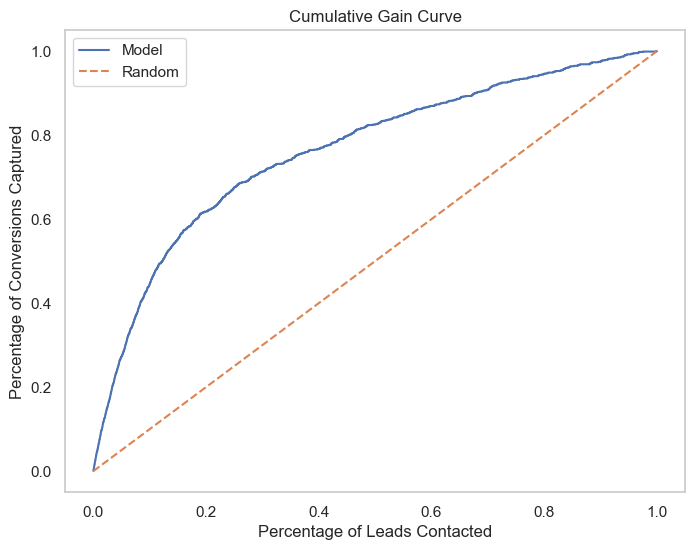

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(df_gain['perc_leads'], df_gain['perc_conversions'], label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('Percentage of Leads Contacted')
plt.ylabel('Percentage of Conversions Captured')
plt.title('Cumulative Gain Curve')
plt.legend()
plt.grid()
plt.show()


## Final Conclusion

This notebook demonstrates how a lead scoring model can be used in practice to support sales prioritization.

### Main Outcomes

- Leads can be ranked by estimated conversion probability
- Top-ranked segments show significantly higher conversion rates than the overall average
- The model enables more efficient allocation of sales and marketing resources

### Business Interpretation

Rather than treating all leads equally, the company can focus on the most promising opportunities first.

👉 This improves efficiency, increases expected conversions, and creates a more actionable sales workflow.

### Next Step

The next logical step is to operationalize this system through model export, batch scoring, or API deployment.
